Saved figure:
  .//rwp_low_20230802_Ufield_barbs_CST.png


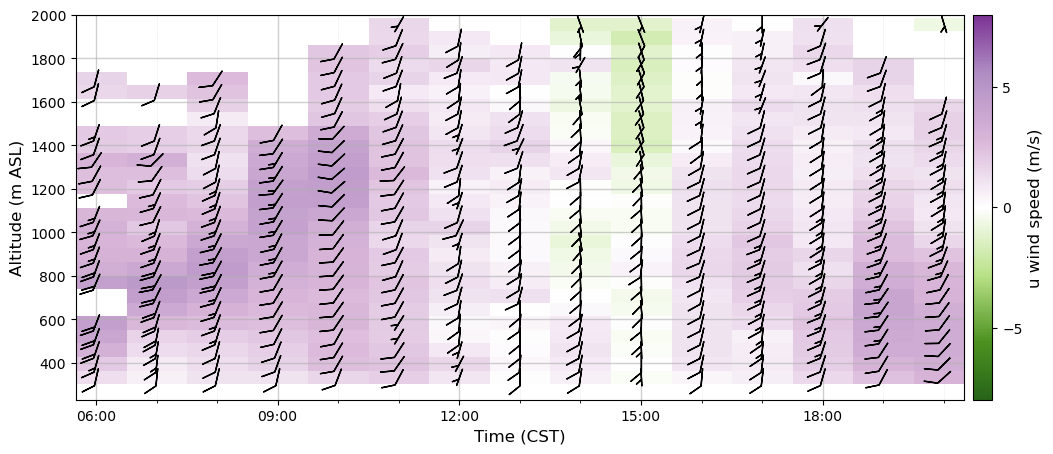

In [14]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
RWP consensus winds at ATMOS: CST figure
U-component colormap + black barbs on a CST axis (UTC–6),
for 00:00–24:00 CST on 2 August 2023. Need data from 3 August 2023 as well to cover the full day in CST.
xlim of the final figure is from 06:00 to 20:00 with xticks every 3 hours to be consistent with Figure S15. 
"""

from pathlib import Path
from datetime import datetime, timedelta
import glob

import numpy as np
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.dates import date2num, HourLocator, DateFormatter

# ======================================================
# CONFIG: Data file path and date
# ======================================================
DIR = "./"
DATE_CST = "2023-08-02"

OUT_BASE = f"{DIR}/rwp_low_20230802"

SITE_ELEV_M = 230.0      # Argonne altitude (m ASL)
MAX_ALT_M = 2000         # Top of plot (m ASL)

# Barb styling
BARB_LENGTH = 5
BARB_SIZES = dict(spacing=0.25, height=0.6, width=1.0, emptybarb=0.35)
BARB_PIVOT = "middle"
BARB_INCREMENTS_MS = dict(
    half=2.57222,    # 5 kt
    full=5.14444,    # 10 kt
    flag=25.7222     # 50 kt
)

TARGET_TIME_SAMPLES = 28
TARGET_Z_SAMPLES = 26

FILL = -9999.0

# Style (similar to original)
mpl.rcParams.update({
    "figure.figsize": (12, 5),
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.2,
    "grid.linewidth": 0.5,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
})

# ======================================================
# HELPERS
# ======================================================
def find_nc(dirpath, ymd):
    pat = str(Path(dirpath) / f"anl915rwpwindcon.a1.{ymd}.nc")
    matches = glob.glob(pat)
    return matches[0] if matches else None


def extract_raw(ds):
    """Extract UNALIGNED low-mode arrays."""
    base = "base_time_low"
    time = "time_low"
    zvar = "height_p_low"
    uvar = "u_wind_low"
    vvar = "v_wind_low"
    svar = "spd_low"

    t0 = int(ds[base].values)
    toff = np.asarray(ds[time].values, float)
    epoch_utc = t0 + toff  # seconds since epoch (UTC)

    z_km_agl = np.asarray(ds[zvar].values, float)
    z_m_asl = z_km_agl * 1000.0 + SITE_ELEV_M

    U = np.asarray(ds[uvar].values, float)
    V = np.asarray(ds[vvar].values, float)
    S = np.asarray(ds[svar].values, float)

    U[U == FILL] = np.nan
    V[V == FILL] = np.nan
    S[S == FILL] = np.nan

    return epoch_utc, z_m_asl, U, V, S


def align_heights(packs):
    """
    Align heights across days by intersecting z (m ASL).
    packs: list of (t, z_m, U, V, S) for each file.
    Returns:
        t_all, z_common, U_all, V_all, S_all
    """
    zs = [np.round(p[1], 1) for p in packs]
    common = zs[0]
    for z in zs[1:]:
        common = np.intersect1d(common, z)

    idxs = []
    for z in zs:
        idx = [np.argmin(np.abs(z - val)) for val in common]
        idxs.append(np.array(idx, int))

    t_all = np.concatenate([p[0] for p in packs], axis=0)
    U_all = np.concatenate([packs[k][2][:, idxs[k]] for k in range(len(packs))], axis=0)
    V_all = np.concatenate([packs[k][3][:, idxs[k]] for k in range(len(packs))], axis=0)
    S_all = np.concatenate([packs[k][4][:, idxs[k]] for k in range(len(packs))], axis=0)

    return t_all, common.astype(float), U_all, V_all, S_all


# ======================================================
# MAIN
# ======================================================
def main():

    # --------------------------------------------------
    # Load both days and align heights
    # --------------------------------------------------
    packs = []
    for ymd in ["20230802", "20230803"]:
        f = find_nc(DIR, ymd)
        if not f:
            print(f"[WARN] Missing file for {ymd}")
            continue
        ds = xr.load_dataset(f, decode_cf=False)
        packs.append(extract_raw(ds))
        ds.close()

    if not packs:
        raise RuntimeError("No input NetCDFs found.")

    t_all, z_common, U_all, V_all, S_all = align_heights(packs)

  
    # --------------------------------------------------
    # Convert epoch seconds → UTC datetimes
    # --------------------------------------------------
    t_utc_all = np.array([
        datetime.utcfromtimestamp(float(s)) for s in t_all
    ])

    # --------------------------------------------------
    # Force CST axis: CST = UTC - 6 hours
    # --------------------------------------------------
    t_cst_all = np.array([dt - timedelta(hours=6) for dt in t_utc_all])

    # CST day boundaries (naive datetimes)
    day_start_cst = datetime.fromisoformat(DATE_CST).replace(hour=0, minute=0, second=0)
    day_end_cst = day_start_cst + timedelta(days=1)

    # Mask 00–24 CST for that date
    mask = (t_cst_all >= day_start_cst) & (t_cst_all < day_end_cst)

    t_cst_sel = t_cst_all[mask]
    U = U_all[mask]
    V = V_all[mask]
    S = S_all[mask]

    # Numeric times for plotting
    t_num_cst = date2num(t_cst_sel)

    # Height trimming
    zmask = z_common <= MAX_ALT_M
    z_plot = z_common[zmask]
    U = U[:, zmask]
    V = V[:, zmask]
    S = S[:, zmask]

    # Thinning
    nt, nz = U.shape
    dt = max(1, nt // TARGET_TIME_SAMPLES)
    dz = max(1, nz // TARGET_Z_SAMPLES)
    tidx = np.arange(0, nt, dt)
    zidx = np.arange(0, nz, dz)

    # --------------------------------------------------
    # Colormap and normalization
    # --------------------------------------------------
    vmin_u, vmax_u = -8, 8

    cmap_u = LinearSegmentedColormap.from_list(
        "purple_green_custom",
        [
            (0.00, "#276419"),
            (0.15, "#4d9221"),
            (0.32, "#b8e186"),
            (0.50, "#ffffff"),
            (0.68, "#d8b5d8"),
            (0.85, "#af8dc3"),
            (1.00, "#7b3294"),
        ]
    )
    norm_u = Normalize(vmin=vmin_u, vmax=vmax_u)

    # --------------------------------------------------
    # FIGURE – U-field + barbs, CST axis
    # --------------------------------------------------
    fig4, ax4 = plt.subplots(figsize=(12, 5))

    # Meshgrid for full field
    TT, ZZ = np.meshgrid(t_num_cst, z_plot, indexing="ij")

    pcm4 = ax4.pcolormesh(
        TT, ZZ, U,
        cmap=cmap_u,
        norm=norm_u,
        shading="auto"
    )
    cbar4 = plt.colorbar(pcm4, ax=ax4, pad=0.01, fraction=0.035)
    cbar4.set_label("u wind speed (m/s)")
    cbar4.set_ticks([-5, 0, 5])

    # Thinned barbs
    TTb, ZZb = np.meshgrid(t_num_cst[tidx], z_plot[zidx], indexing="ij")
    Ub = U[tidx][:, zidx]
    Vb = V[tidx][:, zidx]
    good = np.isfinite(Ub) & np.isfinite(Vb)

    ax4.barbs(
        TTb[good], ZZb[good],
        Ub[good], Vb[good],
        length=BARB_LENGTH,
        sizes=BARB_SIZES,
        barb_increments=BARB_INCREMENTS_MS,
        barbcolor="black",
        flagcolor="black",
        pivot=BARB_PIVOT,
        zorder=15,
    )

    # ======================================================
    # Custom x-limits: focus on 06 CST → 20 CST with padding
    # ======================================================

    start_plot_cst = datetime(2023, 8, 2, 5, 40)   # ~1 hour before 06 CST (extra 20 min before for padding)
    end_plot_cst   = datetime(2023, 8, 2, 20, 20)  # ~1 hour after 20 CST (extra 20 min after for padding)

    ax4.set_xlim(
        date2num(start_plot_cst),
        date2num(end_plot_cst)
    )

    # Axes formatting
    ax4.set_ylim(SITE_ELEV_M, MAX_ALT_M)
    ax4.set_ylabel("Altitude (m ASL)")
    ax4.set_xlabel("Time (CST)")

    ax4.xaxis.set_major_locator(HourLocator(byhour=range(0, 24, 3)))
    ax4.xaxis.set_major_formatter(DateFormatter("%H:%M"))
    ax4.xaxis.set_minor_locator(HourLocator(interval=1))

    ax4.grid(which="major", linestyle="-", linewidth=1.0, alpha=0.6)
    ax4.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.4)

    fig4.savefig(f"{OUT_BASE}_Ufield_barbs_CST.png", dpi=600)
    fig4.savefig(f"{OUT_BASE}_Ufield_barbs_CST.pdf")

    print("Saved figure:")
    print(f"  {OUT_BASE}_Ufield_barbs_CST.png")


if __name__ == "__main__":
    main()
